In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from calibration import load_data, separate_ch_sig, rectify, bandpass_filter, lowpass_filter


calibration before stim analysis

In [ ]:
# dir = r"C:\Users\User\Desktop\Maryam_Test_Files\MTS_Test\2025 - 10 - 20"
dir = r"C:\Users\Maryam\OneDrive - UW\Quals\MTS-test\2025 - 10 - 20"
date_timestamp = "2025 - 10 - 20_16 - 28 - 43"
file_extension = ".csv"


In [ ]:
_calib = r"\calibration\MTS_Test_RawFormattedEMGData_" + date_timestamp + file_extension
_filt_calib = r"\calibration\MTS_Test_FiltEMGData_" + date_timestamp + file_extension
_env_calib = r"\calibration\MTS_Test_EnvData_" + date_timestamp + file_extension

In [ ]:
_calib = r"\calibration\MTS_Test_RawFormattedEMGData_" + date_timestamp + file_extension
_filt_calib = r"\calibration\MTS_Test_FiltEMGData_" + date_timestamp + file_extension
_env_calib = r"\calibration\MTS_Test_EnvData_" + date_timestamp + file_extension

In [ ]:
_calib = r"\calibration\trial1\MTS_Test_RawFormattedEMGData_2025 - 10 - 16_15 - 46 - 33.csv"
calib = pd.read_csv(dir+_calib)
plt.plot(calib.EMG1)

In [ ]:
calib = pd.read_csv(dir + _calib)
filt = pd.read_csv(dir + _filt_calib)
env = pd.read_csv(dir + _env_calib)

In [ ]:
EMG1_calib = []
for i, val in enumerate(calib.EMG1):
    EMG1_calib.append(float(val))

In [ ]:
plt.plot(EMG1_calib)

In [ ]:
filt_1 = []
env_1 = []
for i, ch in enumerate(filt["emg channel"]):
    if ch == 1:
        filt_1.append(filt["filt signal"][i])
for i, ch in enumerate(env["emg channel"]):
    if ch == 1:
        env_1.append(env["enveloped signal"][i]*10)


In [ ]:
plt.plot(np.arange(10000), np.array(filt_1[0:10000]))
plt.plot(np.arange(10000), np.array(env_1[0:10000]))

In [ ]:
# plt.plot(calib.EMG1[0:-1])
plt.plot(EMG1_calib[0:-1])
plt.plot(np.arange(len(filt_1)-1), np.array(filt_1[0:-1]))

plt.plot(np.arange(len(env_1)-1), np.array(env_1[0:-1]))
plt.title("Raw data, online filter, and envelope")
plt.ylabel("signal")
plt.xlabel("samples")

calibration after stim analysis

In [2]:
dir = r"C:\Users\Maryam\OneDrive - UW\Quals\MTS-test\2025 - 10 - 20"
date_timestamp = "2025 - 10 - 20_16 - 28 - 43"
file_extension = ".csv"

In [3]:
_raw = r"\MTS_Test_RawFormattedEMGData_" + date_timestamp + file_extension
_filt = r"\MTS_Test_FiltEMGData_" + date_timestamp + file_extension
_env = r"\MTS_Test_EnvData_" + date_timestamp + file_extension

In [4]:
env = pd.read_csv(dir + _env)
raw = pd.read_csv(dir + _raw)
filt = pd.read_csv(dir + _filt)

In [5]:
#extract realtime filter and enveloped data values
r_filt = []
r_env = []
r_stim = []
r_thresh = []
for i, ch in enumerate(filt["emg channel"]):
    if ch == 1:
        r_filt.append(filt["filt signal"][i])

for i, ch in enumerate(env["emg channel"]):
    if ch == 1:
        r_env.append(env["enveloped signal"][i])
        r_stim.append(env["stim command"][i])
        r_thresh.append(env["threshold"][i])

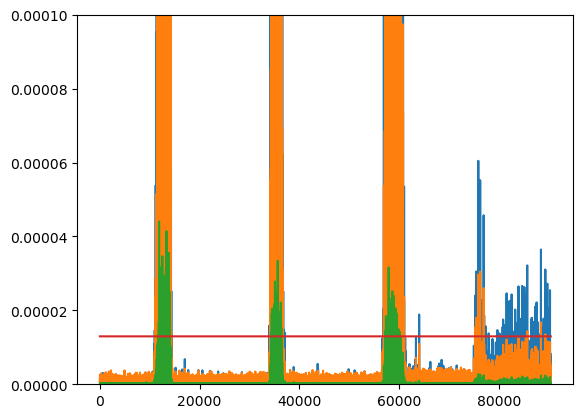

In [6]:
# plt.plot(r_stim)
plt.plot(raw.EMG1)
plt.plot(r_filt)
plt.plot(r_env)
plt.plot(r_thresh)
plt.ylim([0,0.0001])
plt.show()

In [7]:
#setup for comparison with offline filters and enveloped data
o_filter = bandpass_filter(raw.EMG1)
o_env = lowpass_filter(rectify(o_filter), lowcut=2)

b:  [ 0.23130798  0.         -0.46261596  0.          0.23130798]
a:  [ 1.         -2.1400946   1.55288934 -0.59223286  0.18337778]
z: 0.23130797944426512
b:  [0.00313176 0.00313176]
a:  [ 1.         -0.99373647]
z: 0.0031317642291927056


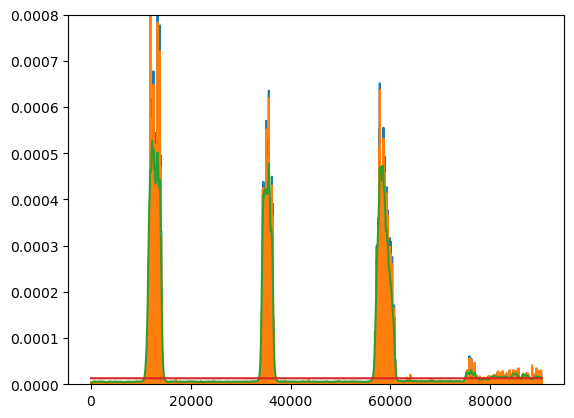

In [8]:
plt.plot(raw.EMG1)
plt.plot(o_filter)
plt.plot(o_env*4)
plt.plot(r_thresh)
plt.ylim([0,0.0008])
plt.show()

In [9]:
for i, val in enumerate(r_env):
    r_env[i] = val*15

b:  [ 0.23130798  0.         -0.46261596  0.          0.23130798]
a:  [ 1.         -2.1400946   1.55288934 -0.59223286  0.18337778]
z: 0.23130797944426512
b:  [0.00313176 0.00313176]
a:  [ 1.         -0.99373647]
z: 0.0031317642291927056


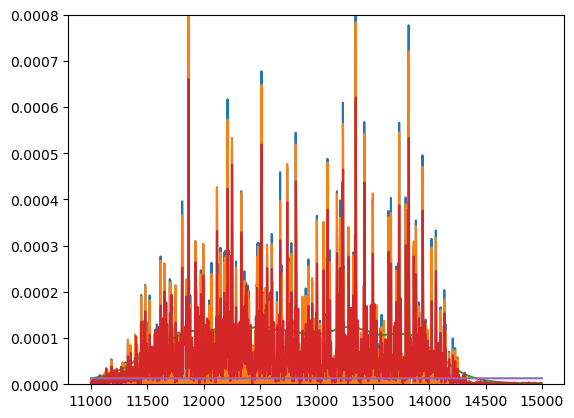

In [10]:
o_filter = bandpass_filter(raw.EMG1)
o_env = lowpass_filter(rectify(o_filter), lowcut=2)

low = 11000
high = 15000
plt.plot(raw.EMG1[low:high])
plt.plot(np.arange(low,high),o_filter[low:high])
plt.plot(np.arange(low,high),o_env[low:high])
plt.plot(np.arange(low,high),r_env[low:high])
plt.plot(np.arange(low,high), r_thresh[low:high])
plt.ylim([0,0.0008])
plt.show()